# Supplementary Material S1: Expanded descriptions of the food web

reconstruction approaches

# Model descriptions

## Structural models

### Random model

The Erdős–Rényi random graph model \[@erdos1959\] assigns a fixed number of links ($L$) uniformly at random among a set of $S$ nodes (species). Ecologically, this model assumes that interactions occur independently of species identity, such that no node-level traits influence whether a link is present or absent. As a result, links are randomly distributed throughout the network, producing a food web that is minimally biologically structured while preserving the specified richness ($S$) and connectance ($L/S^{2}$). Because connectance is defined as $Co = L/S^{2}$, specifying either $L$ or $Co$ fully determines network density. Here we parameterise the model using $L$ as derived from the drawn Co value *i.e.,* $L = Co \times S^{2}$.

### Niche model

The niche model \[@williams2000\] assumes that trophic interactions are structured by a one-dimensional feeding niche. Each species is assigned a niche range, and all species whose niche values fall within this range are potential prey, allowing for cannibalism. Niche ranges are assigned stochastically, with their sizes constrained in part by the specified connectance ($Co$) of the network. Although several extensions of the niche model have been proposed, increasing model complexity does not appear to improve its ability to reproduce empirically realistic network structure \[@williams2008\].

Formally, each of the $S$ species is assigned a niche value $n_i$ drawn uniformly from the interval \[0,1\]. Species $i$ consumes all species whose niche values fall within a contiguous range of width $r_i$, with the center of this range ($c_i$) drawn uniformly from the interval $[ \frac{r_i}{2}, n_i ]$. The range width $r_i$ is determined by drawing a value from a beta distribution on \[0,1\] with expected value $2 \times Co$, which is then multiplied by $n_i$ to achieve the desired connectance.

## Realised models

### Allometric diet breadth model

The Allometric Diet Breadth Model (ADBM; @petchey2008) is grounded in optimal foraging theory and predicts trophic interactions based on energetic considerations. In this framework, consumers select prey to maximize their rate of energy intake, such that diet composition is determined by the energetic profitability of potential resources. The model therefore predicts both the number of trophic links and their arrangement based on species-level traits, specifically consumer diet breadth.

The energy intake rate ($K$) of a consumer is defined as:

$$K = \frac{\sum_{i=1}^{k}\lambda_{ij}E_{i}}{1+\sum_{i=1}^{k}\lambda_{ij}H_{ij}}$$

where $\lambda_{ij}$ is the encounter rate between consumer $j$ and resource $i$, defined as the product of attack rate ($A_i$) and resource density ($N_i$), $E_i$ is the energy content of the resource, and $H_{ij}$ is the handling time. Handling time depends on the ratio of consumer to resource body mass and is defined as:

$$H_{ij} = \frac{h}{b - \frac{M_{i}}{M_{j}}} if \frac{M_{i}}{M_{j}} < b$$

and

$$H_{ij} = \infty \geq b$$

All bioenergetic and allometric parameters were fixed to the default values reported in @petchey2008 and were not estimated from data. Attack rates, handling times, and resource densities were parameterised as power-law functions of body mass using empirically derived scaling exponents, while energy content was assumed to scale linearly with prey body mass. Body mass was therefore the sole varying biological input to the model across replicates, with all other parameters held constant.

### Allometric trophic network model

The Allometric Trophic Network (ATN; @brose2006) model also uses body mass to infer trophic interactions but places greater emphasis on mechanical constraints associated with consumer–resource size relationships. Interactions are determined by allometric rules based on the ratio of consumer ($M_i$) to resource ($M_j$) body mass and are further constrained to produce networks that resemble realized food webs \[@schneider2016; @gauzens2023\].

The probability of a trophic interaction ($P_{ij}$) between consumer $i$ and resource $j$ is defined using a Ricker function parameterized by the optimal body-mass ratio ($R_{opt}$) and the shape parameter $\gamma$:

$$P_{ij} = (L \times \exp(1 - L))^{\gamma}$$

where

$$L = \frac{M_{i}}{M_{j} \times R_{opt}}$$

An optional threshold can be applied to $P_{ij}$, such that interaction probabilities below the threshold are set to zero, further constraining network structure.

All bioenergetic and allometric parameters were fixed to the default values reported in @petchey2008, which were originally evaluated across a range of empirical food webs spanning both terrestrial and aquatic systems. Although these parameterisations are not derived specifically from paleo communities, previous work has shown that ADBM structural predictions are relatively robust to variation in scaling exponents across ecosystem types. As our analyses focus on comparative differences among reconstruction approaches rather than absolute parameter calibration, using a consistent, empirically grounded parameter set provides a standardised baseline for comparison.

### Body size ratio model

The body size ratio model \[@rohr2010\] infers trophic interactions probabilistically based on the ratio of consumer ($M_i$) to resource ($M_j$) body mass. To represent predator–prey body-mass ratios as a feeding niche, the model modifies this ratio using a quadratic function in log-transformed mass space, producing a unimodal interaction probability distribution. In its simplified form, the probability of an interaction between consumer $i$ and resource $j$ is defined as:

$$P_{ij} = \frac{p}{1+p}$$

where

$$p = exp[\alpha + \beta log(\frac{M_{i}}{M_{j}}) + \gamma log^{2}(\frac{M_{i}}{M_{j}})]$$

The original latent-trait formulation introduced by @rohr2010 included an additional interaction term, $v_i \delta f_j$. For simplicity, and following @yeakel2014, this term is omitted here and only the equation above is used. Parameter values are taken directly from @yeakel2014, which were estimated using Serengeti food web data: $\alpha = 1.41$, $\beta = 3.75$, and $\gamma = 1.87$.

Although the body size ratio model is parameterised using empirical estimates derived from terrestrial systems (*e.g.,* Serengeti food webs), its applicability to paleo communities may be less direct. To address this, we explicitly evaluated the sensitivity of network structure (see *Parameterisation of the body-mass ratio model* section) to variation in key parameters governing interaction probabilities.

## Feasibility models

### Paleo food web inference model

The Paleo Food Web Inference Model (PFIM; @shaw2024) infers trophic interactions using a rule-based framework applied to discrete trait categories, such as habitat preference and body size. For a given consumer–resource pair, an interaction is deemed feasible only if all trait-based rules across multiple rule classes are satisfied.

The original implementation of PFIM includes an optional downsampling step adapted from @roopnarine2006, which prunes interactions using a power-law distribution defined by the expected link distribution. This approach is conceptually aligned with earlier feasibility-based methods \[@roopnarine2006\] but does not require explicit assignment of taxa to trophic guilds. We follow the implementation described by @shaw2024, as these approaches are based on the same underlying feasibility framework and are expected to generate highly similar network structures.

# Network construction

## Overview of the comparative framework

All food-web reconstruction approaches were evaluated within a unified comparative framework in which each model generated ensembles of binary interaction networks under identical species richness and sampling structure. This design allows direct comparison of emergent network properties while controlling for variation in species identity, temporal sampling, and stochastic realisations. Each reconstructed food web is represented as a directed binary adjacency matrix $A_{ij}$, where $A_{ij} = 1$ denotes a trophic interaction from consumer $i$ to resource $j$, and $A_{ij} = 0$ otherwise. Unless otherwise stated, all analyses are based on binary interaction structure.

Reconstruction approaches differ primarily in their generative assumptions: (i) random models assume interactions occur independently of species identity, (ii) niche- and body-size–based models impose trait-structured constraints in latent or observed trait space, (iii) allometric models incorporate mechanistic energetic or size-ratio constraints on interaction feasibility, and (iv) feasibility-based models (PFIM) impose deterministic rule sets derived from discrete ecological traits.

For each model and time period, multiple stochastic realisations were generated to capture intrinsic variability. Reported results therefore reflect ensemble-level properties rather than single deterministic networks.

## Simulating networks

Food webs were generated for each reconstruction approach using a consistent simulation framework designed to ensure comparability across models. For each model and time period, multiple independent network realisations were constructed (replicates), allowing stochastic variation in link structure to be quantified and propagated through subsequent analyses. All networks were built with identical species richness and based on a shared species pool, ensuring that differences in network structure arise solely from model-specific assumptions about interaction formation.

For models requiring continuous traits (*e.g.,* ADBM, ATN, and body size ratio models), species body masses were assigned probabilistically for each replicate. Body mass values were drawn from a predefined distribution (log-scaled), and these values served as the primary input governing interaction probabilities or energetic constraints. As a result, each replicate represents a unique realisation of trait space, generating variation in network topology even under identical model parameterisation.

In contrast, feasibility-based approaches (*e.g.,* PFIM) used discrete trait assignments (e.g., trophic guild, motility, tiering), which were fixed for a given time period. Stochasticity in these models arises primarily through optional link pruning or sampling procedures rather than variation in trait values.

For each model–time combination, an ensemble of network replicates (n ≈ 50 per configuration) was generated. These ensembles form the basis for all downstream analyses, including structural comparisons, beta diversity calculations, and extinction simulations. By maintaining consistent replication across models, the framework captures both deterministic differences among reconstruction approaches and their inherent stochastic variability.

### Table S1. Summary of parameterisation across food web reconstruction models

| Model | Parameter | Value / Distribution | Source / Implementation | Notes |
|--------------|--------------|------------------|--------------|--------------|
| **Random** | Species richness (S) | Empirical (per community) | Input data | Shared across all models |
|  | Number of links (L) | (\$L = Co S^2\$), with (\$Co U(0.07, 0.15)\$) | This study | Connectance randomly drawn per replicate |
| **Niche** | Species richness (S) | Empirical | Input data |  |
|  | Connectance (Co) | (\$Co U(0.07, 0.15)\$) | This study | Determines niche range distribution |
|  | Niche values (\$n_i\$) | (\$U(0,1)\$) | Standard niche model |  |
|  | Range distribution | Beta distribution with mean | Standard niche model | As in @williams2000 |
| **ADBM** | Body mass (\$M_i\$) | Uniform within size classes (see below) | This study | Primary varying trait |
|  | Biomass (\$B_i\$) | (\$M_i^{-3/4}\$) | Metabolic scaling | Used in encounter rates |
|  | Attack rate, handling time, energy scaling | Fixed allometric exponents | @petchey2008 | Default parameter set |
|  | Resource density (\$N_i\$) | Derived from biomass | This study | Implicit in encounter term |
| **ATN / L-matrix** | Body mass (\$M_i\$) | Uniform within size classes | This study | Same as ADBM |
|  | Producer identity | Binary (from tiering) | Empirical data | Constrains trophic structure |
|  | Interaction rules | Deterministic size-structured constraints | Schneider et al. (2016) implementation | I |
| **Body-mass ratio (BMR)** | Body mass (\$M_i\$) | Uniform within size classes | This study |  |
|  | α (optimum ratio) | 1.41 | @yeakel2014 | Serengeti-derived |
|  | β (niche width) | 3.73 | @yeakel2014 |  |
|  | γ (scaling / threshold) | −1.90 | @yeakel2014 |  |
|  | Functional form | Quadratic in log mass ratio | @rohr2010 | Simplified formulation |
| **PFIM (downsampled)** | Trait rules | Feeding, motility, tiering | @shaw2024 |  |
|  | Downsampling parameter (y) | 100.0 | This study | Power-law pruning |
| **All models** | Body size classes | Discrete categories (tiny → gigantic) | Empirical data | Mapped to continuous mass |
|  | Body mass sampling | Uniform within class ranges | This study | Re-sampled per replicate |
|  | Replicates | (n = 100) | This study | Captures stochastic variation |

## Extinction simulation framework

To evaluate structural robustness, reconstructed networks were subjected to simulated species removal sequences representing alternative disturbance regimes. These included random extinction, degree-ordered extinction (based on generality and vulnerability), and trait-ordered extinction sequences derived from ecological hierarchies as defined in @dunhill2024.

Following each removal event, secondary extinctions were computed dynamically as species losing all incoming trophic resources. This process generates cascading extinction dynamics dependent on underlying network topology.

All extinction regimes were applied consistently across reconstruction models and network realisations to ensure comparability of cascading structural responses.

## Effect of Body Size Sampling Method on Network Metrics

To assess whether the choice of body size sampling distribution (uniform, lognormal, or truncated lognormal) influences the estimated structure of ecological networks, we computed partial eta-squared (η²) values for each network metric within each reconstruction model. This approach isolates the effect of body size distribution while controlling for model-specific variation.

Across all models and network metrics, the effect of body size sampling method was extremely small. Most η² values were effectively zero (\<0.01), indicating that the choice of distribution had negligible influence on metrics such as connectance, generality, vulnerability, and various motif counts. Only a few metrics in the ATN and ADBM models showed slightly higher effects (η² ≈ 0.17 for max trophic level and the number of linear chains), but these remained the exception rather than the rule.

These findings justify using any of the tested body size sampling approaches for our simulations, as the structural conclusions drawn from the networks are robust to this methodological choice. Consequently, analyses of network metrics and comparisons across reconstruction models are not confounded by the specific form of the synthetic body size distribution.

### Figure S1. Effect of Body Size Sampling Method on Network Metrics

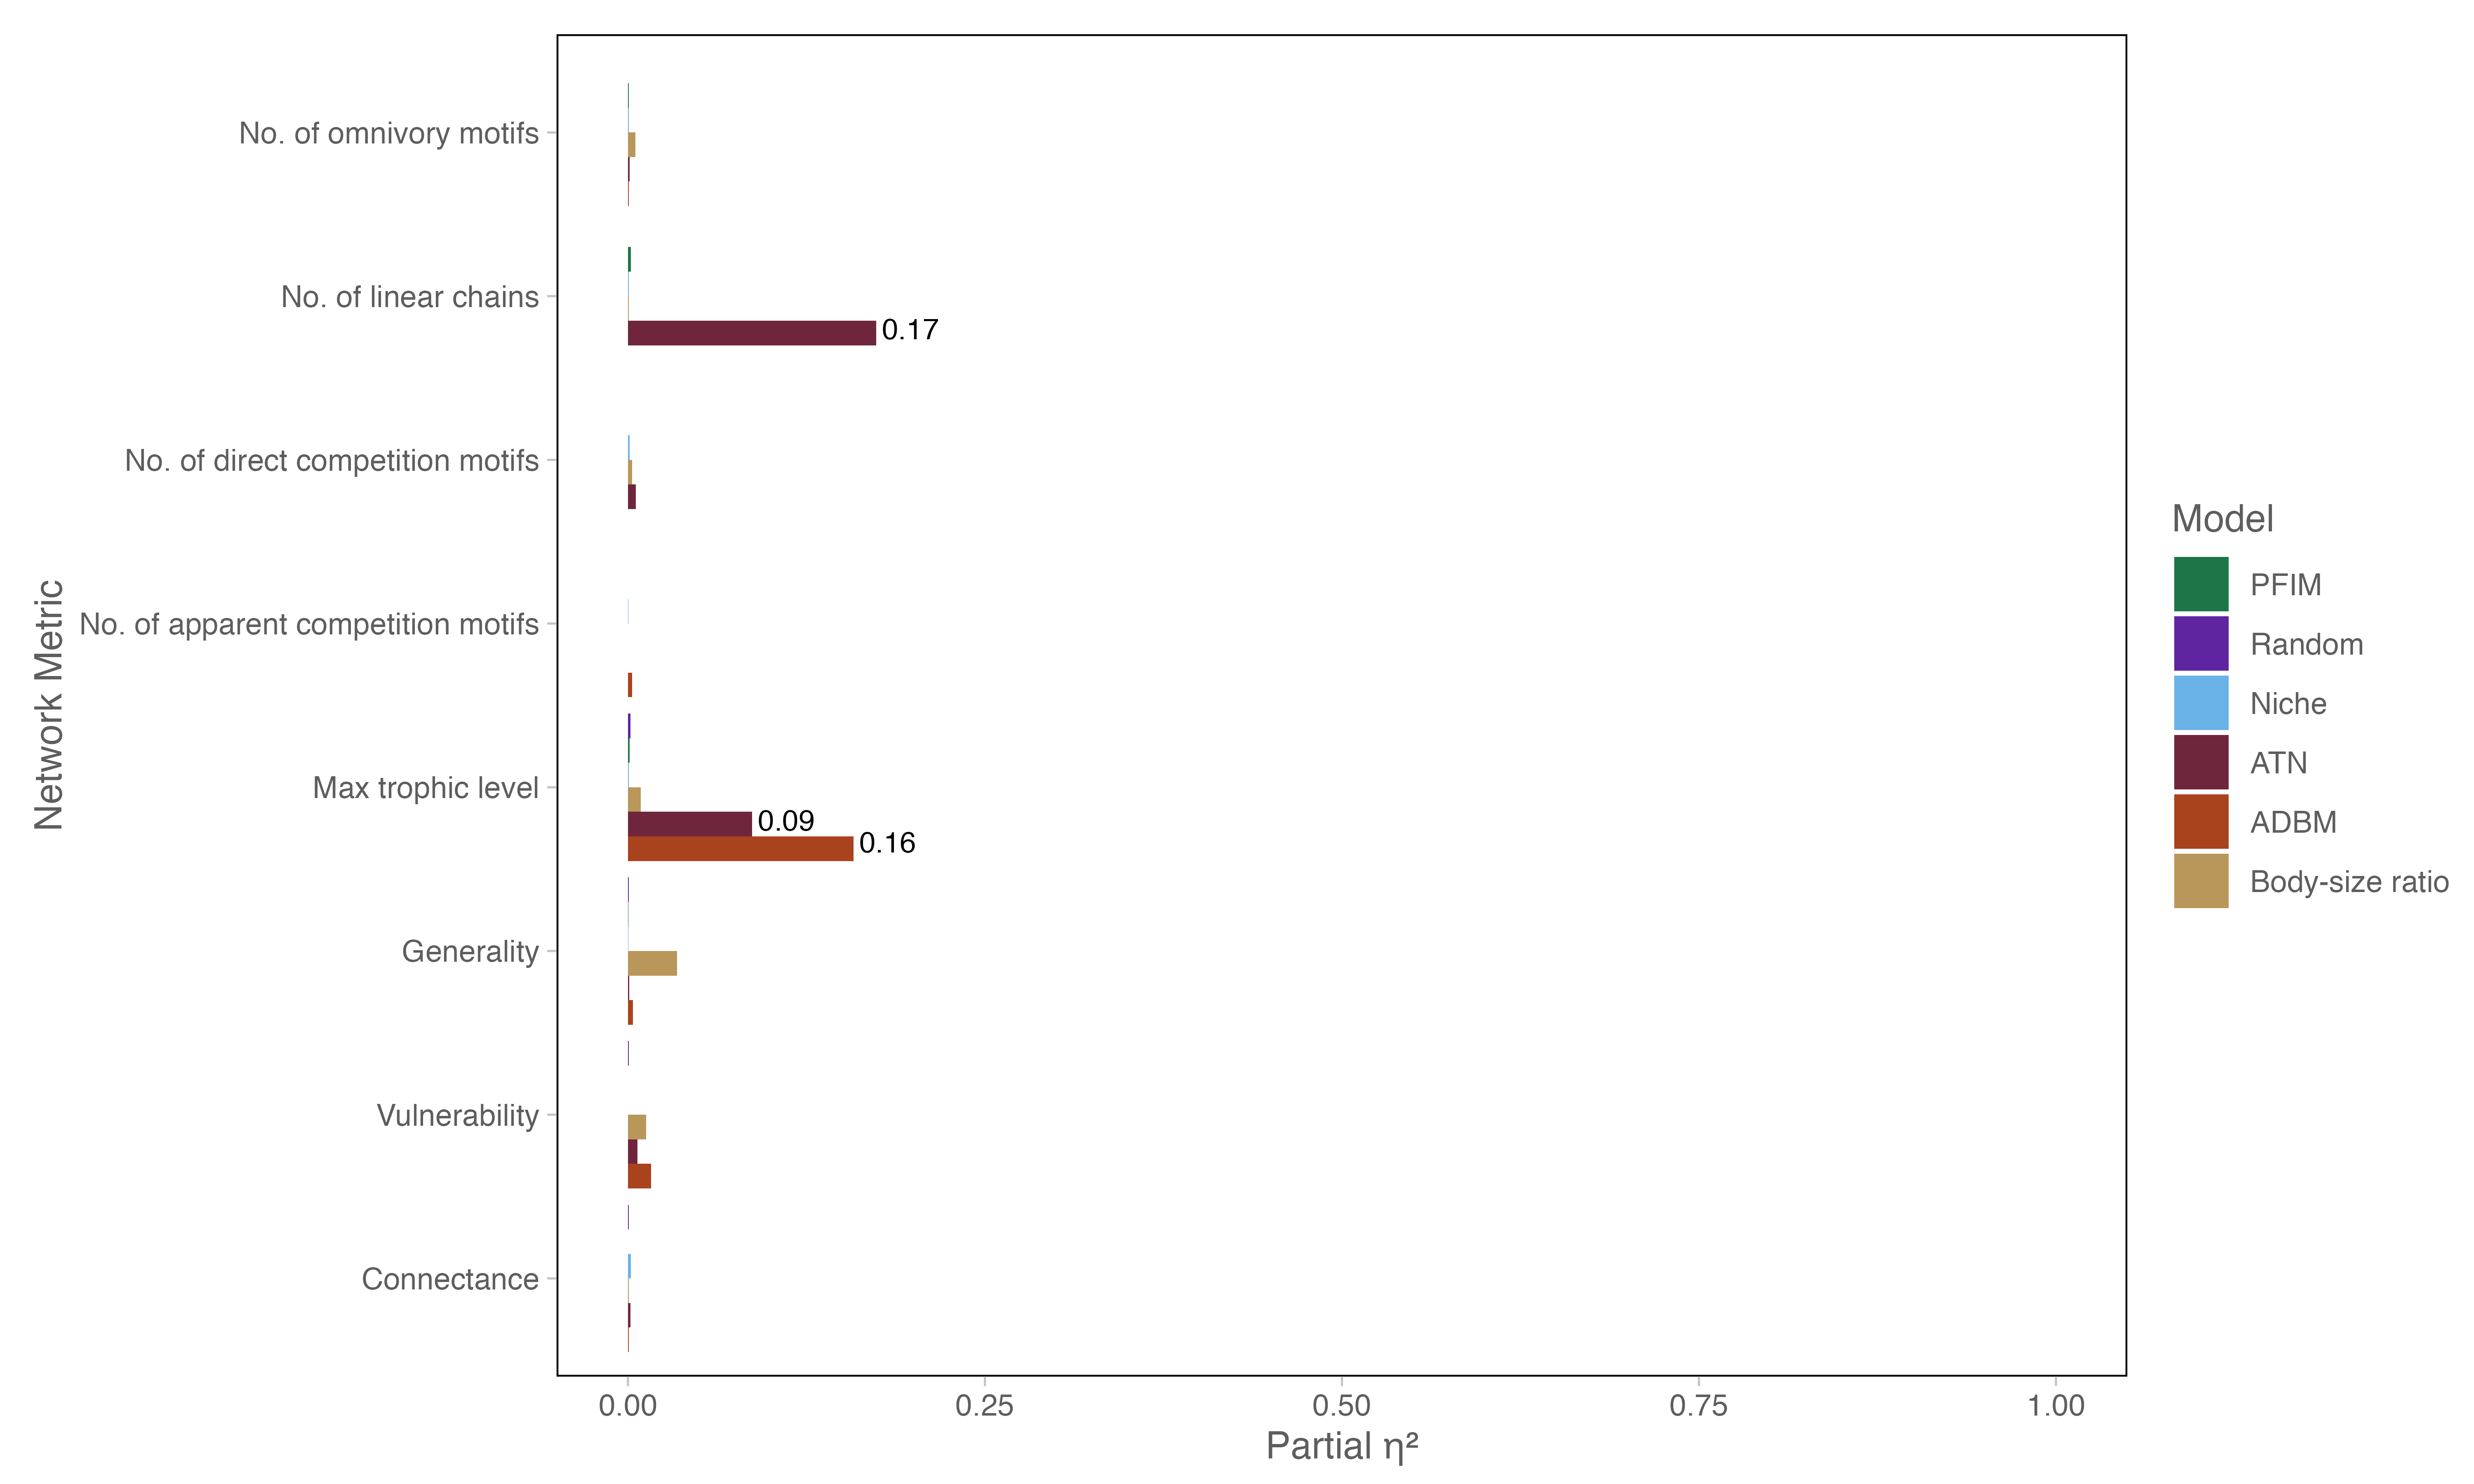

Metrics where η² was notably higher are labelled directly on the bars. The figure highlights that, for the majority of network properties and models, η² values are extremely low (\<0.01), confirming that the body size distribution choice has negligible impact on network structure. A few exceptions appear for the ATN model, but these are limited to specific metrics (*e.g.,* number of linear chains).

## Parameterisation of the body-mass ratio model

To evaluate the sensitivity of the body-mass ratio (BMR) reconstruction model to assumptions about feeding niche structure and interaction filtering, we defined a set of seven parameter configurations spanning biologically plausible perturbations of the interaction probability function.

The BMR model defines trophic link probability as a function of predator–prey body-mass ratios and interaction structure is governed by three parameters controlling niche position, niche width, and interaction thresholding.

We explored seven parameter sets (Table Sx), constructed to isolate distinct mechanistic perturbations of this function.

### Table S2. Parameter perturbation classes for the BMR model

| Parameter set | α (optimum ratio) | β (niche width) | γ (threshold / scaling) | Interpretation |
|--------------|--------------|--------------|--------------|------------------|
| baseline | 1.41 | 3.73 | -1.90 | Serengeti-calibrated reference model |
| narrow_niche | 1.41 | 2.5 | -1.90 | Increased dietary specialization |
| wide_niche | 1.41 | 5.0 | -1.90 | Relaxed dietary specialization |
| shifted_optimum_low | 1.0 | 3.73 | -1.90 | Smaller optimal predator–prey ratio |
| shifted_optimum_high | 1.8 | 3.73 | -1.90 | Larger optimal predator–prey ratio |
| strict_threshold | 1.41 | 3.73 | -2.5 | Stronger interaction filtering |
| relaxed_threshold | 1.41 | 3.73 | -1.0 | Weaker interaction filtering |

These parameterisations represent structured deviations from the empirically calibrated baseline, allowing us to separate effects of niche breadth, interaction optima, and interaction filtering strength.

### Effects of body-mass interaction parameterisation on network structure

Multivariate analysis revealed that parameterisation of the body-mass ratio interaction model significantly influenced emergent food-web structure (PERMANOVA, R² = 0.227, F = 136.38, p = 0.001). Although statistically highly significant, this effect explains approximately one-fifth of total variation in multivariate network structure, indicating that parameter choice systematically shapes but does not dominate network topology.

Redundancy analysis (RDA) confirmed that this variation is primarily low-dimensional. The first canonical axis captured the majority of explainable variation among parameter sets (RDA1 F = 781.06, p = 0.001), with a secondary axis also contributing meaningfully (RDA2 F = 32.52, p = 0.001), while subsequent axes were comparatively minor (RDA3 F = 4.46, p = 0.031; RDA4 non-significant). This indicates that differences among parameterisations are structured along a small number of dominant gradients rather than reflecting fully distinct multivariate regimes.

Inspection of RDA loadings indicates that this structure is primarily driven by variation in connectance and measures of trophic organisation (notably generality and vulnerability), whereas richness and trophic level contribute comparatively weakly. Thus, parameter variation primarily reshapes interaction density and the distribution of consumer–resource breadth, rather than fundamentally altering overall network organisation.

Despite significant differences in multivariate centroids, there was no evidence that parameter sets differ in multivariate dispersion (betadisper, F = 0.154, p = 0.988). This indicates that while parameter choice shifts the mean position of networks in multivariate space, it does not systematically alter the variability of structures generated within each parameter regime.

### Justification for baseline parameterisation

Given that parameter variation induces structured but low-dimensional shifts in network topology, we retain the baseline parameter set (α = 1.41, β = 3.73, γ = −1.90; derived from empirical Serengeti estimates) for subsequent analyses.

This choice is justified for three reasons:

- **Empirical grounding:** The baseline parameters are derived from well-resolved empirical food webs and therefore represent biologically realistic interaction constraints rather than arbitrary tuning.

- **Structural robustness:** Although alternative parameterisations modify network properties, these changes occur primarily along a single dominant structural axis rather than producing qualitatively distinct network regimes. Thus, conclusions are robust to reasonable variation in parameter choice.

- **Avoiding overfitting of generative assumptions:** Exploring extreme parameter regimes (*e.g.,* narrow niche, relaxed thresholds) expands structural variance but does not improve biological realism. Using empirically informed baseline parameters prevents artificially inflating or distorting ecological inference.

Overall, body size interaction parameters influence emergent food web structure in a systematic but constrained manner. Rather than defining fundamentally different network architectures, parameter variation reshapes networks along a single dominant gradient of interaction density and trophic role breadth. This analysis demonstrates that, although parameter choice influences interaction density and trophic breadth, the resulting variation is constrained and does not produce qualitatively different network structures, supporting the applicability of the model to systems that differ from the original calibration context.

## Downsampling PFIM networks

To assess the optimal downsampling parameter to use so as to allow some variation in network structure we downsampled PFIM metawebs across the following range: 5.0, 10.0, 20.0, 30.0, 50.0, 100.0. We then calculated the Jaccard similarity of the resulting adjacency matrices. Across the parameter range the similarity of networks tended to remain above 0.6 and a downsampling parameter of 100 had a mean similarity of 0.86. We thus used a downsampling parameter of 100 for all of the PFIM networks for all statistical analyses.

# Analyses

## Multivariate analysis of network structure

We quantified food-web structure using a suite of macro-, meso-, and micro-scale network metrics capturing global topology, motif composition, and species-level interaction patterns (Table S1). Differences among reconstruction approaches were assessed using a multivariate analysis of variance (MANOVA), with model identity as a fixed factor and the full set of network metrics as response variables. Pillai’s trace was used to assess overall multivariate significance due to its robustness to violations of multivariate normality. To identify the multivariate axes driving differences among models, we performed canonical discriminant analysis (CDA) on the MANOVA model. Canonical variates represent orthogonal linear combinations of network metrics that maximise separation among reconstruction approaches. The contribution of individual metrics to each canonical variate was quantified using canonical structure coefficients (correlations between original metrics and canonical scores).

For visualisation, canonical scores were plotted using linear discriminant analysis (LDA), which yields an equivalent discriminant subspace under equal group priors. Model separation in canonical space was visualised using convex hulls encompassing all network replicates for each reconstruction approach. Univariate analyses of variance and effect sizes (partial η²) were calculated for individual metrics and are reported in the Supplementary Materials for descriptive comparison. Pairwise interaction turnover was quantified using link-based beta diversity, which measures dissimilarity in the identity of trophic interactions between networks and captures differences arising from species turnover or changes in interactions among shared species.

## $\beta$-diversity of network structure

Structural dissimilarity between networks was quantified using interaction-based beta diversity, decomposed into complementary components:

- βS: total interaction dissimilarity

- βWN: interaction rewiring among shared species

- βOS: species turnover–driven interaction change

These metrics partition differences between networks into contributions arising from species loss versus rewiring of interactions among shared species.

Together, they define a multilevel decomposition of structural divergence in food-web topology across models and time periods.

## Quantification of extinction simulation outcomes and model concordance

To evaluate how reconstruction framework influenced inferred extinction dynamics, simulated community states were compared against observed or expected reference states using two complementary approaches. First, deviation in continuous network metrics (e.g., connectance, mean trophic level, modularity) was quantified using mean absolute difference (MAD). For each metric and time step, MAD was calculated as:

$MAD = \frac{1}{n} \sum_{i=1}^{n} | M_{i}^{sim} - M_{i}^{ref}|$

where $M_{i}^{sim}$ is the simulated value and $M_{i}^{ref}$ is the corresponding observed or expected value. MAD was chosen because it provides a scale-preserving measure of deviation that is less sensitive to extreme values than squared-error metrics and allows direct comparison across reconstruction frameworks.

Second, agreement in predicted persistence outcomes was evaluated using a modified True Skill Statistic (TSS) at both node and link levels. At the node level, species were classified as present (persisting) or absent (extinct) in each simulated network and compared to their presence–absence status in the reference community.

At the link level, each possible species pair was classified according to the presence or absence of a trophic interaction in the simulated versus reference network. Thus, link-level evaluation quantified agreement in the retention or loss of specific trophic interactions, independent of overall species richness.

For both node- and link-level classifications, outcomes were assigned as true positives (TP), true negatives (TN), false positives (FP), or false negatives (FN), and TSS was calculated as:

TSS = Sensitivity + Specificity − 1

where Sensitivity = TP/(TP + FN) and Specificity = TN/(TN + FP). TSS ranges from −1 to 1, with 1 indicating perfect agreement, 0 indicating performance no better than random expectation, and negative values indicating systematic disagreement. Because TSS is prevalence-independent, it is appropriate for extinction simulations in which class imbalance may occur (*e.g.,* many persisting species or many absent links).

## ANOVA and temporal dynamics analysis

This script quantifies how food web structure varies across reconstruction models and through time using a combination of two-way ANOVA, effect size estimation, and post hoc comparisons.

First, simulated network outputs are imported and standardised across models and time steps. A suite of network metrics spanning macro- (*e.g.,* connectance, trophic level), meso- (motif structure), and micro-scale (generality, vulnerability) properties are extracted and summarised. Descriptive statistics (mean ± SD) are calculated for each model–metric combination and exported for supplementary reporting.

To test for differences in network structure, separate two-way ANOVAs are fitted for each metric with reconstruction model and time (four stages: pre-, during, early, and late extinction) as fixed factors. Model assumptions are evaluated using Levene’s tests for homogeneity of variance and visual diagnostics (residual–fitted plots and Q–Q plots).

For each ANOVA, partial eta-squared values are calculated to quantify the relative importance of model choice, time, and their interaction. These effect sizes are used to compare how strongly each factor influences different aspects of network structure.

Temporal trajectories are then visualised by plotting mean metric values (± standard error) across time for each model, as well as relative changes from pre-extinction baselines. This allows direct comparison of how models differ in their predicted structural responses to extinction and recovery.

To assess agreement among models, the coefficient of variation (CV) is calculated across models for each metric and time step, providing a measure of inter-model disagreement through time.

Post hoc pairwise comparisons (Tukey-adjusted) are performed to identify which models differ significantly within each time step. These results are summarised as heatmaps showing the magnitude and significance of pairwise differences.

Finally, ANOVA effect sizes and model disagreement (CV) are combined into a synthesis plot, highlighting which metrics are primarily driven by model choice versus temporal dynamics, and where models converge or diverge most strongly.

# References